<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter5/5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 교차검증과 그리드 서치

검증 세트가 필요한 이유?

교차검증?

그리드 서치와 랜덤 서치를 이용해 최적의 성능을 내는 하이퍼파라미터 찾기

이전까지는 문제를 간단히 하기 위해 테스트 세트를 사용해 모델을 평가했는데 테스트 세트로 일반화 성능을 올바르게 예측하려면 가능한 한 테스트 세트를 사용하지 말아야한다. 모델을 만들고 나서 마지막에 딱 한 번만 사용하는것이 좋은데 그렇다면 max_depth 매개변수를 사용한 하이퍼파라미터 튜닝을 어떻게 할 수 있을까?

## 검증 세트
테스트 세트를 사용하지 않으면 과대/과소 적합 판단이 어렵다. 테스트 세트를 사용하지 않고 이를 측정하는 방법은 훈련 세트를 또 나누는 것이다.

In [1]:
#데이터 가져오기
import pandas as pd

wine = pd.read_csv('https://bit.ly/wine_csv_data')

In [3]:
#특성과 타깃
data = wine[['alcohol', 'sugar', 'pH']]
target = wine['class']

In [4]:
#훈련세트와 테스트세트 나누기(테스트 세트 20%로)
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

#훈련세트를 훈련세트와 검증세트로 나누기(검증세트를 20%로)
sub_input, val_input, sub_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

#확인
print(sub_input.shape, val_input.shape, test_input.shape)

(4157, 3) (1040, 3) (1300, 3)


In [5]:
#결정트리 모델 훈련(train을 sub, test를 val로 생각하면 됨)
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(sub_input, sub_target)

#스코어 확인(과대적합)
print(dt.score(sub_input, sub_target))
print(dt.score(val_input, val_target))

0.9971133028626413
0.864423076923077


## 교차검증
보통 많은 데이터를 훈련에 사용할수록 좋은 모델인데 검즈으 세트를 너무 조금 뗴어 놓으면 검증 점수가 들쭉날쭉하고 불안정할 것이다. 이럴때 교차 검증을 이용하면 안정적인 검증 점수를 얻고 훈련에 더 많은 데이터를 사용할 수 있다.

교차 검증은 검증 세트를 떼어 내어 평가하는 과정을 여러번 반복함. 그 다음 점수를 평균하여 최종 검증 점수를 얻는다.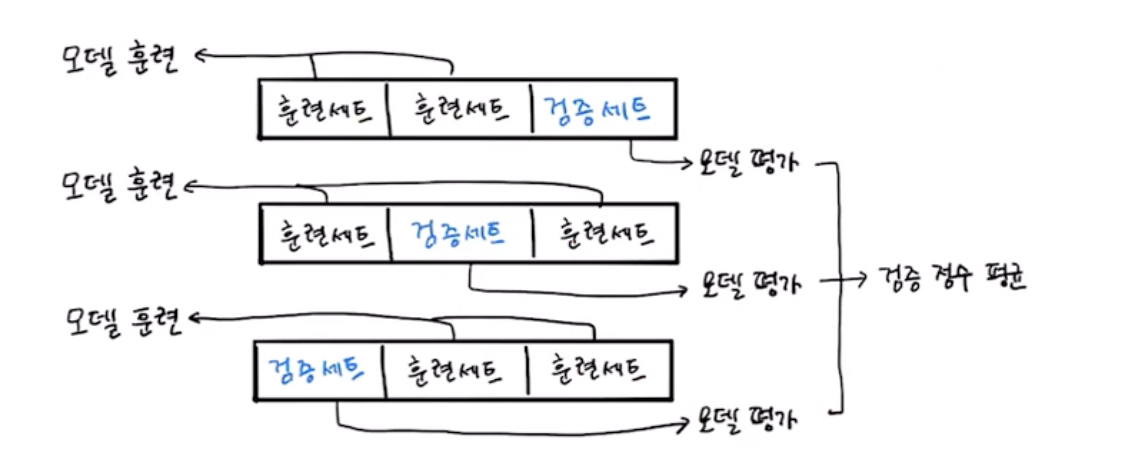

In [6]:
#기본 5폴드 검증
from sklearn.model_selection import cross_validate

scores = cross_validate(dt, train_input, train_target)
print(scores)

{'fit_time': array([0.01354003, 0.01349998, 0.01370978, 0.01353884, 0.01392484]), 'score_time': array([0.00352073, 0.00311399, 0.00310302, 0.00329494, 0.00338006]), 'test_score': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}


In [7]:
#점수 평균
import numpy as np
print(np.mean(scores['test_score']))

0.855300214703487


In [10]:
#분할기를 사용한 교차검증
from sklearn.model_selection import StratifiedKFold

#기본 5-폴드
scores = cross_validate(dt, train_input, train_target, cv=StratifiedKFold())
print(np.mean(scores['test_score']))

#분류기
splitter = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)
scores = cross_validate(dt, train_input, train_target, cv=splitter)
print(np.mean(scores['test_score']))

0.855300214703487
0.8574181117533719


## 그리드서치
하이퍼파라미터 탐색을 자동화해 주는 도구. 탐색할 매개변수를 나열하면 교차 검증을 수행하여 가장 좋은 검증 점수의 매개변수 조합을 선택한다.

In [12]:
from sklearn.model_selection import GridSearchCV

params = {'min_impurity_decrease': [0.0001, 0.0002, 0.0003, 0.0004, 0.0005]}

In [13]:
#그리드서치 객체만들기
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params,n_jobs=-1)

#그리드서치의 cv매개변수 기본값은 5. 따라서 min_impurity_decrease 값마다 5-폴드 교차 검증 수행하므로 총 25개의 모델을 훈련한다. 따라서 n_jobs 매개변수에서 병령 실행에 사용할 CPU코어 수를 지정할수 있는데 기본값은 1이다. -1은 모든 코어를 사용한다.

In [15]:
#훈련시키기
gs.fit(train_input, train_target)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'min_impurity_decrease': [0.0001, 0.0002, 0.0003,
                                                   0.0004, 0.0005]})

In [16]:
#best_estimator에 저장되어있어 이것을 사용
dt = gs.best_estimator_

#스코어 확인
print(dt.score(train_input, train_target))

0.9615162593804117


In [18]:
#최적의 매개변수 출력
print(gs.best_params_)

#각 매개변수에서 수행한 교차 검증의 평균 점수 출력
print(gs.cv_results_['mean_test_score'])

{'min_impurity_decrease': 0.0001}
[0.86819297 0.86453617 0.86492226 0.86780891 0.86761605]


과정 정리

1. 탐색할 매개변수 지정

2. 훈련세트에서 그리드 서치를 수행하여 최상의 평균 검증 점수가 나오는 매개변수 조합을 찾기. 이 조합은 그리드 서치 객체에 저장

3. 그리드 서치는 최상의 매개변수에서(교차검증에 사용한 훈련 세트가 아니라) 전체 훈련 세트를 사용해 최종 모델을 훈련. 이 모델도 그리드 서치 객체에 저장

In [21]:
#조금 더 복잡한 매개변수 조합(9 * 15 * 10 = 1350, 1350 * 5(5-폴드 교차검증) = 6750개의 모델)
params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),
          'max_depth': range(5, 20, 1),
          'min_samples_split': range(2, 100, 10)
          }

In [24]:
#그리드 서치 실행
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs = -1)

In [26]:
#훈련시키기
gs.fit(train_input, train_target)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': range(5, 20),
                         'min_impurity_decrease': array([0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008,
       0.0009]),
                         'min_samples_split': range(2, 100, 10)})

In [29]:
#최상의 매개 변수 조합확인
print(gs.best_params_)

#최상의 교차 검증 점수확인
print(np.max(gs.cv_results_['mean_test_score']))

{'max_depth': 14, 'min_impurity_decrease': np.float64(0.0004), 'min_samples_split': 12}
0.8683865773302731


아쉬운점?

매개변수의 간격을 0.0001 혹은 1로 설정하였는데 이렇게 간격을 둔 근거가 없다. 이보다 더 좁거나 넓은 간격을 시도할수는 없나?

## 랜덤서치(확률 분포 선택)
매개변수 값의 목록을 전달하는 것이 나닌 매개변수를 샘플링 할 수 있는 확률 분포 객체를 전달함.

In [34]:
#싸이파이 사용
from scipy.stats import uniform, randint

#10개 숫자 샘플링
rgen = randint(0, 10)
rgen.rvs(10)


array([6, 6, 5, 3, 3, 4, 7, 7, 9, 3])

In [35]:
#1000개의 숫자 샘플링 후 각 숫자의 개수
np.unique(rgen.rvs(1000), return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([115,  94, 114,  87, 103, 100,  98, 104,  94,  91]))

In [37]:
#0과 1사이에서 10개의 실수 샘플링
ugen = uniform(0, 1)
ugen.rvs(10)

array([0.68143979, 0.65408572, 0.26524515, 0.63198708, 0.32079382,
       0.91638143, 0.54671241, 0.70809677, 0.6758907 , 0.02368403])

이 두 클래스 객체를 넘겨주고 총 몇 번을 샘플링해서 최적의 매개변수를 찾으라고 명령할 수 있다.

In [38]:
#매개변수 조합(랜덤)
params = {'min_impurity_decrease': uniform(0.0001, 0.001),
          'max_depth': randint(20, 50),
          'min_samples_split': randint(2, 25),
          'min_samples_leaf': randint(1, 25),
          }

In [40]:
#랜덤 서치 클래스로 훈련(샘플링 횟수는 n_iter=)
from sklearn.model_selection import RandomizedSearchCV

rs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), params, n_iter = 100, n_jobs=-1,random_state = 42)

rs.fit(train_input, train_target)

RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dd0d4340080>,
                                        'min_impurity_decrease': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7dd0d4341460>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dd0d4342a80>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dd0d4342e10>},
                   random_state=42)

In [41]:
#최상의 매개 변수 조합확인
print(rs.best_params_)

#최상의 교차 검증 점수확인
print(np.max(rs.cv_results_['mean_test_score']))

{'max_depth': 39, 'min_impurity_decrease': np.float64(0.00034102546602601173), 'min_samples_leaf': 7, 'min_samples_split': 13}
0.8695428296438884


In [44]:
#최적의 모델은 이미 전체 훈련 세트로 훈련되어 best_estimator_ 속성에 저장
dt = rs.best_estimator_

#스코어 확인
print(dt.score(test_input, test_target))

0.86


와인 선별 작업 성능을 올리기 위해 결정트리의 다양한 하이퍼파라미터르르 시도해봐야함

-> 이 과정에서 테스트 세트를 사용하면 테스트 세트에 맞춰모델을 훈련하게 됨.

-> 테스트 세트는 최종 모델을 선택할 때까지 사용하지 말아야하는데 그러려면 또 다른 세트가 필요하고 그것이 검증세트

-> 훈련세트에서 검증세트를 덜어내서 만들고 검증 점수가 안정적으로 되기 위해 여러 번 반복할 수 있어야 하고 이를 교차 검증이라고 함.

-> 최종 검증 점수는 모든 폴드의 검증 점수를 평균하여 계산

-> 교차 검증을 사용해 다양한 하이퍼파라미터를 탐색

-> 테스트하고 싶은 매개변수 리스트를 만들어 이 과정을 자동화하는 그리드 서치를 사용.

-> 매개변수 값을 샘플링하여 요율적인 하이퍼파라미터 탐색을 할 수 있음
